# **Word2Vec Skip-gram**

## Ringkasan Proses

Notebook ini membahas cara kerja model Word2Vec dengan arsitektur Skip-gram pada dua level:

1. Contoh kecil untuk memahami pasangan target-konteks dan representasi vektor kata.
2. Penerapan pada dataset berita untuk mengevaluasi pengaruh preprocessing dan parameter model terhadap akurasi klasifikasi.

Tujuan utama adalah melihat bagaimana pemilihan window, ukuran vektor, dan preprocessing memengaruhi kualitas representasi kata sebelum digunakan untuk klasifikasi dokumen.

## **1. Penerapan Word2Vec Skip-gram pada teks**

In [1]:
from gensim.models import Word2Vec

# 1. Siapkan 3 kalimat panjang yang sudah di-tokenisasi
sentences = [
    ["mahasiswa", "teknik", "informatika", "belajar", "pemrograman", "python", "dan", "basis", "data", "sql"],
    ["mahasiswa", "teknik", "informatika", "membuat", "aplikasi", "web", "menggunakan", "laravel", "dan", "docker"],
    ["dosen", "sistem", "informasi", "mengajar", "mata", "kuliah", "kecerdasan", "buatan", "di", "kampus"]
]

# Tentukan ukuran window
window_size = 2
vector_size = 6  # Ukuran vektor embedding


In [2]:
# 2. Fungsi manual untuk menampilkan pasangan Target dan Konteks (Metode Skip-gram)
print("=== DAFTAR PASANGAN TARGET DAN KONTEKS (Window = 2) ===")
for idx_sent, sentence in enumerate(sentences, 1):
    print(f"\nKalimat {idx_sent}: {' '.join(sentence)}")
    for i, target_word in enumerate(sentence):
        # Tentukan batas kiri dan kanan berdasarkan window
        start = max(0, i - window_size)
        end = min(len(sentence), i + window_size + 1)
        
        # Ambil kata konteks di sekitar target (kecuali target itu sendiri)
        context_words = [sentence[j] for j in range(start, end) if j != i]
        
        print(f"  Target: '{target_word:<12}' -> Konteks: {context_words}")

print("\n" + "="*50 + "\n")

=== DAFTAR PASANGAN TARGET DAN KONTEKS (Window = 2) ===

Kalimat 1: mahasiswa teknik informatika belajar pemrograman python dan basis data sql
  Target: 'mahasiswa   ' -> Konteks: ['teknik', 'informatika']
  Target: 'teknik      ' -> Konteks: ['mahasiswa', 'informatika', 'belajar']
  Target: 'informatika ' -> Konteks: ['mahasiswa', 'teknik', 'belajar', 'pemrograman']
  Target: 'belajar     ' -> Konteks: ['teknik', 'informatika', 'pemrograman', 'python']
  Target: 'pemrograman ' -> Konteks: ['informatika', 'belajar', 'python', 'dan']
  Target: 'python      ' -> Konteks: ['belajar', 'pemrograman', 'dan', 'basis']
  Target: 'dan         ' -> Konteks: ['pemrograman', 'python', 'basis', 'data']
  Target: 'basis       ' -> Konteks: ['python', 'dan', 'data', 'sql']
  Target: 'data        ' -> Konteks: ['dan', 'basis', 'sql']
  Target: 'sql         ' -> Konteks: ['basis', 'data']

Kalimat 2: mahasiswa teknik informatika membuat aplikasi web menggunakan laravel dan docker
  Target: 'mahasiswa  

In [3]:
# 3. Latih model Word2Vec dengan arsitektur Skip-gram (sg=1)
model = Word2Vec(
    sentences=sentences, 
    vector_size=vector_size, 
    window=window_size, 
    min_count=1, 
    sg=1, 
    seed=42
)

# 4. Menampilkan Hasil Vector Bobot (Embedding) untuk Setiap Kata Unik
print("=== VEKTOR BOBOT AKHIR (Embedding Matrix) per KATA ===")
for word in model.wv.index_to_key:
    vector = model.wv[word]
    formatted_vector = [round(val, 4) for val in vector]
    print(f"Kata: {word:<15} -> Vektor: {formatted_vector}")

=== VEKTOR BOBOT AKHIR (Embedding Matrix) per KATA ===
Kata: dan             -> Vektor: [np.float32(-0.1369), np.float32(0.0913), np.float32(0.0515), np.float32(-0.0204), np.float32(-0.0223), np.float32(0.1195)]
Kata: informatika     -> Vektor: [np.float32(-0.138), np.float32(0.0659), np.float32(-0.0996), np.float32(-0.1354), np.float32(0.0089), np.float32(0.1585)]
Kata: teknik          -> Vektor: [np.float32(0.0786), np.float32(0.087), np.float32(0.0725), np.float32(0.0954), np.float32(0.0044), np.float32(-0.124)]
Kata: mahasiswa       -> Vektor: [np.float32(0.1132), np.float32(-0.0164), np.float32(0.0), np.float32(-0.0431), np.float32(-0.1058), np.float32(0.1423)]
Kata: kampus          -> Vektor: [np.float32(0.0939), np.float32(0.048), np.float32(-0.0324), np.float32(0.1075), np.float32(0.0151), np.float32(-0.0189)]
Kata: di              -> Vektor: [np.float32(-0.0165), np.float32(-0.0909), np.float32(-0.1356), np.float32(0.018), np.float32(0.1293), np.float32(-0.1455)]
Kata: buatan 

## **Implementasi pada data berita**


Tujuan Analisis pada Dataset Berita

Pada bagian ini, data berita digunakan sebagai contoh data nyata untuk menguji apakah model Word2Vec Skip-gram dapat menghasilkan representasi kata yang berguna untuk klasifikasi kategori berita.

Proses yang dilakukan meliputi:
- memahami struktur dan distribusi data,
- memeriksa panjang teks dan kategori,
- melihat kata-kata dominan melalui wordcloud,
- membersihkan teks dengan berbagai skenario preprocessing,
- melatih model Word2Vec dan membangun vektor dokumen,
- mengevaluasi hasil menggunakan Naive Bayes.

Dengan pendekatan ini, kita dapat membandingkan bagaimana variasi preprocessing dan parameter model memengaruhi kualitas representasi teks.

### **1. Install library yang dibutuhkan**

In [4]:
pip install matplotlib seaborn nltk gensim pandas scikit-learn wordcloud

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns


### **2. Understanding data**



Tahap ini penting untuk memastikan dataset yang akan diproses benar-benar sesuai dengan kebutuhan analisis. Kita mengecek:

- jumlah baris dan kolom,
- tipe data masing-masing kolom,
- keberadaan nilai kosong,
- sampel teks berita yang akan diproses,
- distribusi kategori dan panjang teks.

Jika struktur data tidak sesuai, model yang dibangun dapat menghasilkan hasil yang tidak akurat atau sulit diinterpretasi. Oleh karena itu, pemahaman awal data menjadi dasar sebelum preprocessing dan modeling.

In [6]:
# Load dataset
file_path = 'dataset/hasil_scrapping_detik_200.csv'
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama data untuk memastikan data berhasil dibaca
print(f"Total baris dan kolom pada dataset: {df.shape}")
display(df.head(5))
display(df.tail(5))

Total baris dan kolom pada dataset: (200, 7)


,url,category,title,date,text,title_length,text_length
0,https://sport.detik.com/raket/d-8656258/mens-w...,sport,Men's World Tennis Championship: Rifqi dan Raf...,"Kamis, 10 Sep 2026 04:42 WIB","Dua petenis Indonesia, Muhammad Rifqi Fitriadi...",73,1489
1,https://sport.detik.com/raket/d-8656218/kevin-...,sport,Kevin Sanjaya Antusias Lihat Semangat Talenta ...,"Kamis, 10 Sep 2026 01:15 WIB",Audisi Umum PB Djarum 2026 sedang berlangsung ...,67,1829
2,https://sport.detik.com/sport-lain/d-8656170/a...,sport,Atlet Muda Modern Pentathlon Punya Kesempatan ...,"Rabu, 09 Sep 2026 23:50 WIB",Modern Pentathlon akan dipertandingkan dalam m...,63,2861
3,https://sport.detik.com/sport-lain/d-8656176/r...,sport,Romy Tahrizi Juara Nasional Shifter 2026 Bersa...,"Rabu, 09 Sep 2026 23:15 WIB",Kejuaraan Nasional Gokart 2026 yang berlangsun...,60,4791
4,https://sport.detik.com/sport-lain/d-8656181/a...,sport,Asian Games: Ketum PBTI Yakin Taekwondo Bisa B...,"Rabu, 09 Sep 2026 22:22 WIB",Asian Games 2026 tak lama lagi akan dimulai. K...,74,1624


,url,category,title,date,text,title_length,text_length
195,https://finance.detik.com/berita-ekonomi-bisni...,finance,TelkomProperty Ungkap Pemanfaatan Graha Merah ...,"Selasa, 08 Sep 2026 18:50 WIB","PT Graha Sarana Duta (TelkomProperty), sebagai...",76,1948
196,https://finance.detik.com/berita-ekonomi-bisni...,finance,"Harga Masker Mahal Imbas Abu Anak Krakatau, Pe...","Selasa, 08 Sep 2026 17:58 WIB",Ketua Badan Perlindungan Konsumen Nasional (BP...,71,2205
197,https://finance.detik.com/energi/d-8654238/per...,finance,"Pertamina Waspada Solar Subsidi 'Bocor', Selis...","Selasa, 08 Sep 2026 17:53 WIB",PT Pertamina Patra Niaga mewaspadai adanya pot...,71,1682
198,https://finance.detik.com/berita-ekonomi-bisni...,finance,TikTok & Tokopedia Buka Suara soal Kabar Bloki...,"Selasa, 08 Sep 2026 17:43 WIB",Tokopedia dan TikTok Shop buka suara terkait l...,66,3217
199,https://finance.detik.com/berita-ekonomi-bisni...,finance,"Purbaya Ngaku Tak Pusingkan Anggaran BGN, Tahu...","Selasa, 08 Sep 2026 17:32 WIB",Menteri Keuangan (Menkeu) Purbaya Yudhi Sadewa...,71,1889


In [7]:
# Informasi umum mengenai struktur DataFrame
print("=== INFO DATASET ===")
df.info()

print("\n=== CEK MISSING VALUE ===")
print(df.isnull().sum())

print("\n=== CONTOH DATA MENTAH (RAW TEXT) ===")
column_name = 'text' if 'text' in df.columns else df.columns[0]
for i, text_sample in enumerate(df[column_name].head(3), 1):
    print(f"{i}. {text_sample}\n")

# cek distribusinya
if 'label' in df.columns or 'category' in df.columns:
    label_col = 'label' if 'label' in df.columns else 'category'
    print(f"\n=== DISTRIBUSI KELAS ({label_col}) ===")
    print(df[label_col].value_counts())

=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   url           200 non-null    str  
 1   category      200 non-null    str  
 2   title         200 non-null    str  
 3   date          197 non-null    str  
 4   text          200 non-null    str  
 5   title_length  200 non-null    int64
 6   text_length   200 non-null    int64
dtypes: int64(2), str(5)
memory usage: 11.1 KB

=== CEK MISSING VALUE ===
url             0
category        0
title           0
date            3
text            0
title_length    0
text_length     0
dtype: int64

=== CONTOH DATA MENTAH (RAW TEXT) ===
1. Dua petenis Indonesia, Muhammad Rifqi Fitriadi dan Rafalentino Ali Da Costa, melangkah ke Babak Kedua Seri V Men's World Tennis Championship 2026.
Pada laga Babak pertama tunggal putra ITF World Tennis Tour M-15 di Bali Beach Country Club, Nusa Dua, Rabu (9/9/20

=== STATISTIK PANJANG KATA (WORD COUNT) ===
count     200.000000
mean      321.910000
std       140.401298
min        49.000000
25%       238.000000
50%       299.500000
75%       370.000000
max      1037.000000
Name: word_count, dtype: float64


C:\Users\ADVAN\AppData\Local\Temp\ipykernel_8272\3046655590.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', ax=axes[0], palette='Set2')


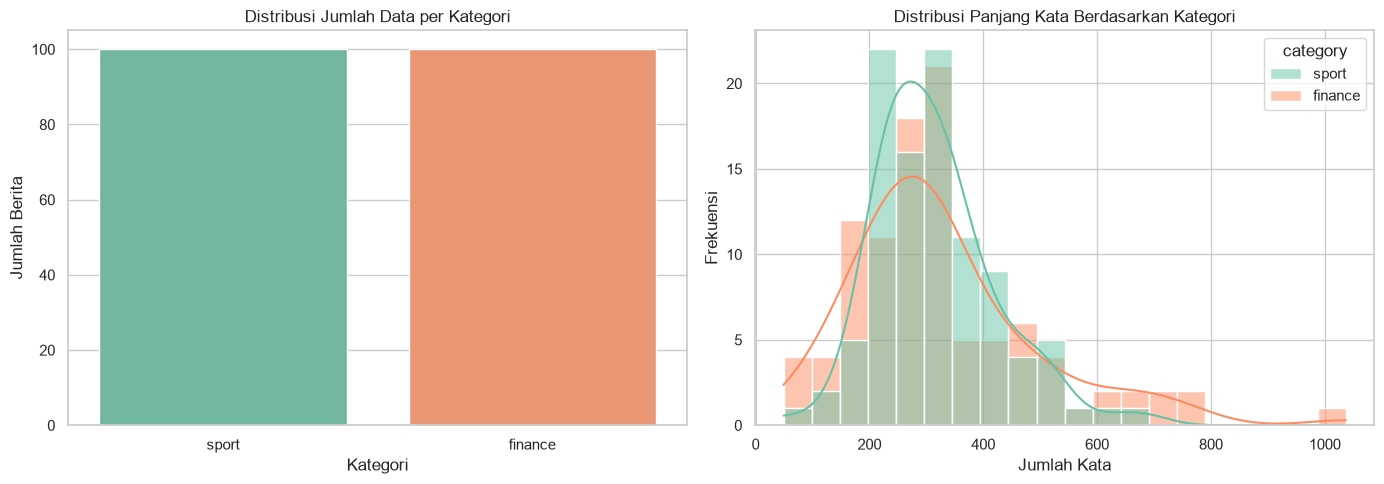

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan setting style seaborn
sns.set_theme(style="whitegrid")

# Hitung jumlah kata per teks berita
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print("=== STATISTIK PANJANG KATA (WORD COUNT) ===")
print(df['word_count'].describe())

# Visualisasi Distribusi Kategori & Panjang Kata
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Distribusi Kategori
sns.countplot(data=df, x='category', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Jumlah Data per Kategori')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Berita')

# 2. Plot Distribusi Panjang Kata (Word Count)
sns.histplot(data=df, x='word_count', hue='category', kde=True, bins=20, ax=axes[1], palette='Set2')
axes[1].set_title('Distribusi Panjang Kata Berdasarkan Kategori')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADVAN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


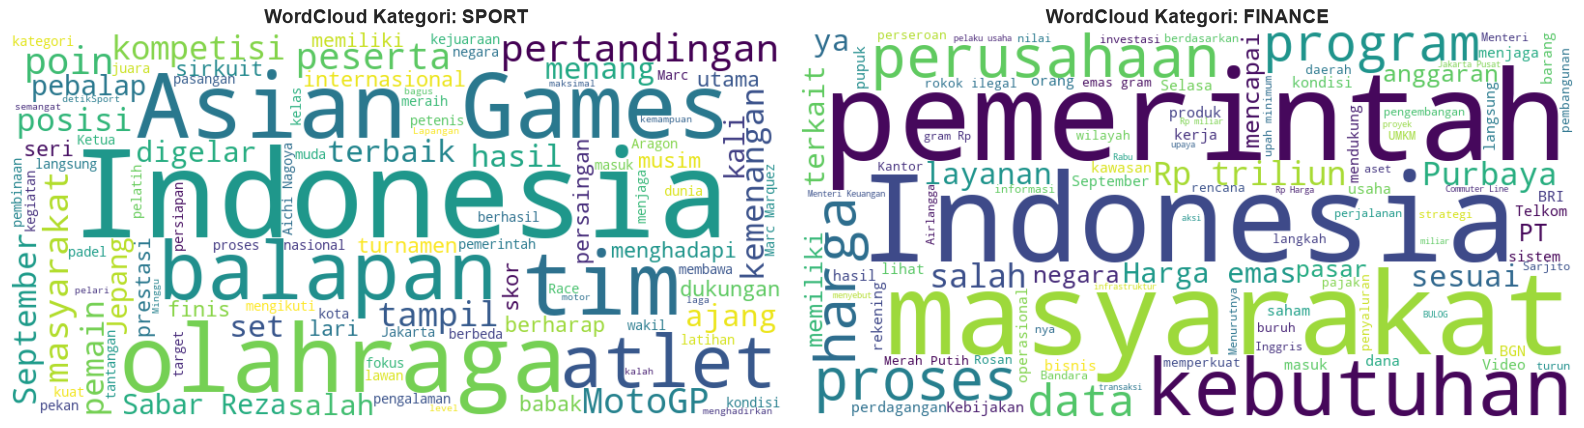

In [9]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
list_stopwords = set(stopwords.words('indonesian'))

categories = df['category'].unique()

fig, axes = plt.subplots(1, len(categories), figsize=(16, 6))

for i, cat in enumerate(categories):
    # Gabungkan semua teks dalam satu kategori tertentu
    text_corpus = " ".join(df[df['category'] == cat]['text'].astype(str))
    
    # Buat objek WordCloud
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white', 
        stopwords=list_stopwords,
        max_words=100,
        colormap='viridis'
    ).generate(text_corpus)
    
    # Plot WordCloud
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'WordCloud Kategori: {cat.upper()}', fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### **3. Preprocessing data**


Preprocessing adalah langkah penting untuk membersihkan teks sebelum dibentuk menjadi representasi kata. Pada notebook ini, kita membuat beberapa skenario untuk melihat pengaruh tiap langkah terhadap hasil model.

Berikut arti masing-masing skenario:
- V1: menghapus tanda baca dan stopword
- V2: mempertahankan tanda baca, menghapus stopword
- V3: menghapus tanda baca, mempertahankan stopword
- V4: menjaga semua komponen teks tanpa pembersihan tambahan

Tujuan dari variasi ini adalah menilai apakah stopword dan tanda baca berkontribusi terhadap kualitas representasi dan akurasi klasifikasi.

In [10]:
import string
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
list_stopwords = set(stopwords.words('indonesian'))

def advanced_preprocessing(text, remove_punct=True, remove_stopword=True, to_lower=True):
    if not isinstance(text, str):
        return []
    
    # 1. Lowercase
    if to_lower:
        text = text.lower()
        
    # 2. Hapus URL (tetap dibersihkan karena URL tidak relevan untuk konteks kata)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 3. Hapus Tanda Baca (Hanya jika remove_punct = True)
    if remove_punct:
        text = text.translate(str.maketrans('', '', string.punctuation))
        
    tokens = text.split()
    
    # 4. Hapus Stopword (Hanya jika remove_stopword = True)
    if remove_stopword:
        tokens = [word for word in tokens if word not in list_stopwords]
        
    return tokens

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADVAN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### **1. Membuat Variasi Dataset Berdasarkan Preprocessing**

In [11]:
text_col = 'text' if 'text' in df.columns else df.columns[4]

# Skenario 1: Clean Punct & Clean Stopword (Standar)
df['tokens_v1'] = df[text_col].apply(lambda x: advanced_preprocessing(x, remove_punct=True, remove_stopword=True, to_lower=True))

# Skenario 2: Tanpa Hapus Tanda Baca (Punctuation di-keep, Stopword dihapus)
df['tokens_v2'] = df[text_col].apply(lambda x: advanced_preprocessing(x, remove_punct=False, remove_stopword=True, to_lower=True))

# Skenario 3: Tanpa Hapus Stopword (Punctuation dihapus, Stopword di-keep)
df['tokens_v3'] = df[text_col].apply(lambda x: advanced_preprocessing(x, remove_punct=True, remove_stopword=False, to_lower=True))

# Skenario 4: Keep Semua (Tanda baca TIDAK dihapus DAN stopword TIDAK dihapus)
df['tokens_v4'] = df[text_col].apply(lambda x: advanced_preprocessing(x, remove_punct=False, remove_stopword=False, to_lower=True))



print("Variasi preprocessing dataset berhasil dibuat!")
print(f"Contoh tokens v1: {df['tokens_v1'].iloc[0][:10]}")
print(f"Contoh tokens v2: {df['tokens_v2'].iloc[0][:10]}")
print(f"Contoh tokens v3: {df['tokens_v3'].iloc[0][:10]}")
print(f"Contoh tokens v4: {df['tokens_v4'].iloc[0][:10]}")

Variasi preprocessing dataset berhasil dibuat!
Contoh tokens v1: ['petenis', 'indonesia', 'muhammad', 'rifqi', 'fitriadi', 'rafalentino', 'ali', 'da', 'costa', 'melangkah']
Contoh tokens v2: ['petenis', 'indonesia,', 'muhammad', 'rifqi', 'fitriadi', 'rafalentino', 'ali', 'da', 'costa,', 'melangkah']
Contoh tokens v3: ['dua', 'petenis', 'indonesia', 'muhammad', 'rifqi', 'fitriadi', 'dan', 'rafalentino', 'ali', 'da']
Contoh tokens v4: ['dua', 'petenis', 'indonesia,', 'muhammad', 'rifqi', 'fitriadi', 'dan', 'rafalentino', 'ali', 'da']


#### **2. Fungsi Pengubah Dokumen ke Vektor (Document Embedding)**

Mengubah Dokumen Menjadi Vektor

Setelah teks selesai diproses menjadi token, langkah berikutnya adalah mengubah setiap dokumen menjadi satu vektor embedding. Metode yang digunakan adalah rata-rata semua vektor kata dalam dokumen:

- setiap kata diambil dari model Word2Vec,
- kata yang tidak ada dalam vocab diabaikan,
- jika dokumen kosong, vektor nol dibuat,
- rata-rata vektor kata menghasilkan representasi dokumen final.

Representasi ini kemudian menjadi input untuk model Naive Bayes, sehingga kualitas embedding kata sangat menentukan hasil klasifikasi akhir.

In [12]:
import numpy as np

def get_document_vector(tokens, model, vector_size):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

### **3. Modeling dan Evaluasi**

#### **1. Pipeline Eksperimen (Word2Vec Skip-gram + Naive Bayes + Evaluasi Akurasi)**



Bagian ini merupakan inti dari eksperimen. Kita melakukan kombinasi beberapa konfigurasi:

- skenario preprocessing: V1 sampai V4,
- ukuran vektor embedding: 50 dan 100,
- ukuran window: 2 dan 5,
- model Word2Vec dengan arsitektur Skip-gram,
- klasifikasi menggunakan Gaussian Naive Bayes.

Setiap kombinasi dilatih dan dievaluasi dengan accuracy on test set. Hasilnya kemudian dibandingkan untuk melihat konfigurasi mana yang paling efektif dalam mengklasifikasikan kategori berita.

In [13]:
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Masukkan skenario v4 ke dalam daftar pengujian
preprocessing_scenarios = {
    'V1_CleanPunct_CleanStop': 'tokens_v1',
    'V2_KeepPunct_CleanStop': 'tokens_v2',
    'V3_CleanPunct_KeepStop': 'tokens_v3',
    'V4_KeepAll_PunctAndStop': 'tokens_v4'
}

vector_sizes = [50, 100]
windows = [2, 5]
y = df['category'].values

results = []

for scen_name, col_token in preprocessing_scenarios.items():
    corpus = list(df[col_token])
    
    for v_size in vector_sizes:
        for win in windows:
            # 1. Latih Word2Vec Skip-gram
            w2v_model = Word2Vec(
                sentences=corpus, 
                vector_size=v_size, 
                window=win, 
                min_count=1, 
                sg=1, 
                seed=42
            )
            
            # 2. Rata-rata vektor dokumen
            X = np.array([get_document_vector(tokens, w2v_model, v_size) for tokens in corpus])
            
            # 3. Split Data (80:20)
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            
            # 4. Modeling Naive Bayes
            nb_model = GaussianNB()
            nb_model.fit(X_train, y_train)
            
            # 5. Evaluasi
            y_pred = nb_model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            
            results.append({
                'Preprocessing': scen_name,
                'Vector_Size': v_size,
                'Window': win,
                'Accuracy': acc
            })

# Tampilkan hasil akhir diurutkan dari akurasi tertinggi
df_results = pd.DataFrame(results)
print("=== HASIL EVALUASI LENGKAP (DENGAN SKENARIO KEEP SEMUA) ===")
print(df_results.sort_values(by='Accuracy', ascending=False).to_string(index=False))

=== HASIL EVALUASI LENGKAP (DENGAN SKENARIO KEEP SEMUA) ===
          Preprocessing  Vector_Size  Window  Accuracy
V1_CleanPunct_CleanStop           50       5     0.925
V1_CleanPunct_CleanStop          100       5     0.925
 V3_CleanPunct_KeepStop           50       5     0.875
 V2_KeepPunct_CleanStop           50       5     0.850
 V3_CleanPunct_KeepStop          100       5     0.800
 V2_KeepPunct_CleanStop          100       5     0.775
V1_CleanPunct_CleanStop          100       2     0.750
V1_CleanPunct_CleanStop           50       2     0.750
 V2_KeepPunct_CleanStop           50       2     0.750
 V2_KeepPunct_CleanStop          100       2     0.725
 V3_CleanPunct_KeepStop           50       2     0.700
V4_KeepAll_PunctAndStop           50       5     0.700
V4_KeepAll_PunctAndStop          100       5     0.700
 V3_CleanPunct_KeepStop          100       2     0.600
V4_KeepAll_PunctAndStop          100       2     0.600
V4_KeepAll_PunctAndStop           50       2     0.575


#### **2. Visualisasi Grafik Akurasi Eksperimen**



Grafik di bawah ini digunakan untuk mempermudah interpretasi hasil eksperimen. Setiap batang mewakili kombinasi preprocessing dan parameter Word2Vec yang menghasilkan akurasi tertentu.

Interpretasi yang biasanya dilakukan:
- konfigurasi dengan akurasi tertinggi paling efektif,
- skenario preprocessing yang paling stabil untuk data ini,
- pengaruh window dan vector_size terhadap kualitas embedding,
- apakah penghilangan stopword atau tanda baca membantu atau justru mengurangi informasi.

Visualisasi ini dibuat agar pembaca dapat secara cepat membandingkan semua kombinasi tanpa harus melihat tabel angka yang panjang.

C:\Users\ADVAN\AppData\Local\Temp\ipykernel_8272\1777119967.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
findfont: Failed to find font weight semibold for Arial, now using 700.


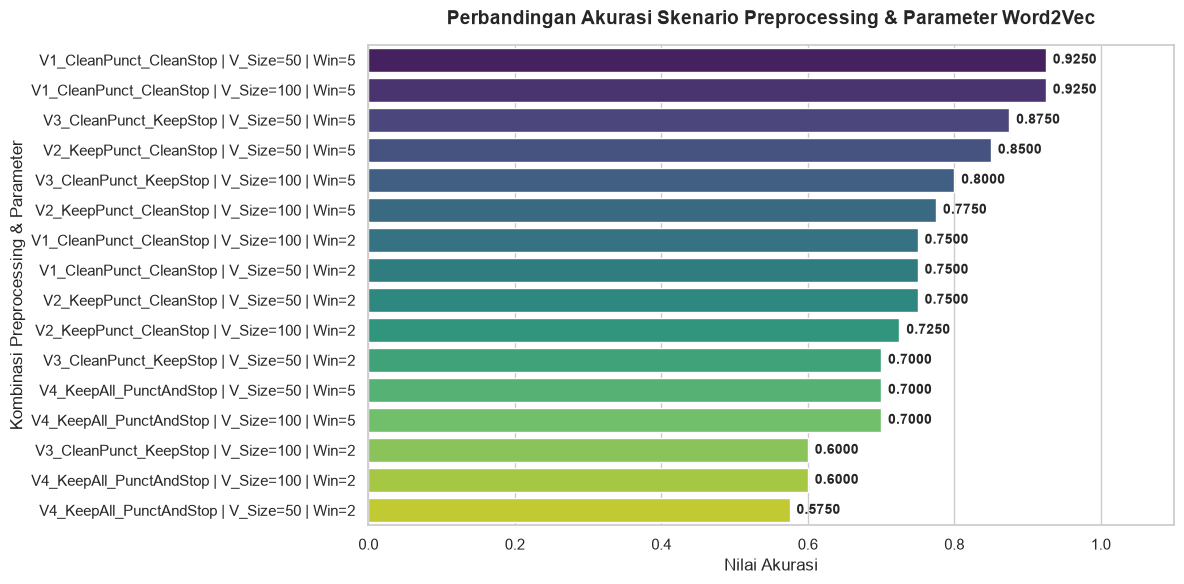

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur ukuran dan tema visualisasi
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Buat kolom gabungan label parameter agar mudah dibaca di sumbu X
df_results['Param_Config'] = df_results['Preprocessing'] + \
                             ' | V_Size=' + df_results['Vector_Size'].astype(str) + \
                             ' | Win=' + df_results['Window'].astype(str)

# Urutkan berdasarkan akurasi tertinggi
df_sorted = df_results.sort_values(by='Accuracy', ascending=False)

# Buat Barplot horizontal
ax = sns.barplot(
    data=df_sorted, 
    x='Accuracy', 
    y='Param_Config', 
    palette='viridis'
)

# Beri judul dan label
plt.title('Perbandingan Akurasi Skenario Preprocessing & Parameter Word2Vec', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nilai Akurasi', fontsize=12)
plt.ylabel('Kombinasi Preprocessing & Parameter', fontsize=12)

# Tambahkan angka akurasi di ujung batang diagram
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.4f}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10, fontweight='semibold')

plt.xlim(0, 1.1)  # Batas sumbu X dari 0 sampai 1.1 agar angka tidak terpotong
plt.tight_layout()
plt.show()